# AutoPulse：汽车销量预测与用户舆情分析


本 Notebook 完整记录项目已完成的各阶段工作，展示每一步的实际操作与成果，对应项目规划（`docs/项目规划.html`）。当前已覆盖：

- **阶段一 · 数据准备**：多源数据采集 → 清洗 → 跨平台 ID 对齐 → 生成分析就绪表
- **阶段二 · 数据筛选与探索性可视化**：连续月份筛选、时序汇总、销量/分类/硬件可视化

后续阶段（销量预测建模、舆情文本深度处理、特征归因、看板交付）完成后将续接到本 Notebook。

## 1. 环境与路径

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BASE = os.path.abspath('..')  # notebook folder is inside AutoPulse
RAW = os.path.join(BASE, 'data', 'raw')
SENTIMENT = os.path.join(BASE, 'data', 'sentiment')
PROC = os.path.join(BASE, 'data', 'processed')
FIG = os.path.join(BASE, 'figures')

for d in [PROC, FIG]:
    os.makedirs(d, exist_ok=True)

print('Project root:', BASE)
print('Raw data dir:', RAW)
print('Sentiment dir:', SENTIMENT)

Project root: /Users/ye/dev/projects/AutoPulse
Raw data dir: /Users/ye/dev/projects/AutoPulse/data/raw
Sentiment dir: /Users/ye/dev/projects/AutoPulse/data/sentiment


### 图表样式（英文标签，简洁浅色风格）

In [2]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif'],
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'text.color': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLORS = {
    'blue': '#2E86AB', 'orange': '#F18F01', 'green': '#3E8914',
    'red': '#C73E1D', 'purple': '#6A4C93', 'teal': '#1B998B', 'gray': '#8D99AE'
}

## 2. 阶段一：数据准备

阶段一是整个项目的数据地基，共完成 **6 份数据集**的采集、清洗与对齐。所有原始数据体积较大且不入库（可由 `scripts/` 下脚本完整复现），本节展示其结构、质量与核心成果。

### 2.1 一次性加载六份数据集

In [3]:
# Stage 1 produced 6 datasets. Load them all up front.
sales = pd.read_csv(os.path.join(RAW, 'sales.csv'))                 # monthly sales
vehicles = pd.read_csv(os.path.join(RAW, 'vehicles.csv'))           # vehicle specs
series_map = pd.read_csv(os.path.join(RAW, 'series_mapping.csv'))   # cross-platform ID bridge
reviews = pd.read_csv(os.path.join(SENTIMENT, 'sentiment_reviews.csv'))    # raw review text
senti = pd.read_csv(os.path.join(SENTIMENT, 'sentiment_summary.csv'))      # series-level sentiment
analysis = pd.read_csv(os.path.join(SENTIMENT, 'analysis_input.csv'))      # aligned analysis table

print('sales      :', sales.shape)
print('vehicles   :', vehicles.shape)
print('series_map :', series_map.shape)
print('reviews    :', reviews.shape)
print('senti(summ):', senti.shape)
print('analysis   :', analysis.shape)

sales      : (33845, 8)
vehicles   : (4334, 92)
series_map : (1139, 12)
reviews    : (40054, 26)
senti(summ): (490, 26)
analysis   : (490, 30)


### 2.2 销量数据（月度，来源：太平洋汽车）

记录每个车系逐月销量，是后续销量预测的目标变量（Y）来源。

In [4]:
print('=== Sales (monthly) — source: PCauto ===')
print('Shape:', sales.shape)
print('Columns:', sales.columns.tolist())
print('Date range: %d-%02d  ->  %d-%02d' % (
    sales.year.min(), sales[sales.year==sales.year.min()].month.min(),
    sales.year.max(), sales[sales.year==sales.year.max()].month.max()))
print('Unique series:', sales.series_id.nunique(), '| Unique brands:', sales.brand.nunique())
print()
print(sales.head(3).to_string())

=== Sales (monthly) — source: PCauto ===
Shape: (33845, 8)
Columns: ['year', 'month', 'series_id', 'series_name', 'brand', 'category', 'monthly_sales', 'data_source']
Date range: 2022-01  ->  2026-05
Unique series: 1122 | Unique brands: 152

   year  month series_id series_name brand category  monthly_sales data_source
0  2023      6   sg10250         212  北汽制造      SUV            426      pcauto
1  2023      7   sg10250         212  北汽制造      SUV            345      pcauto
2  2023      8   sg10250         212  北汽制造      SUV            306      pcauto


### 2.3 车型配置数据（来源：懂车帝）

一行一个车系，包含价格、能源类型、续航、加速等配置字段，是特征变量（X）的来源。

In [5]:
print('=== Vehicle specs — source: Dongchedi ===')
print('Shape:', vehicles.shape, '(1 row = 1 series, %d spec columns)' % vehicles.shape[1])
key = ['series_id', 'series_name', 'brand_name', 'vehicle_class',
       'energy_type', 'official_price_wan', 'battery_range_km', 'acceleration_0_100_s']
print(vehicles[key].head(5).to_string())

=== Vehicle specs — source: Dongchedi ===
Shape: (4334, 92) (1 row = 1 series, 92 spec columns)
  series_id series_name brand_name vehicle_class energy_type  official_price_wan  battery_range_km  acceleration_0_100_s
0       145        宝马3系         宝马           中型车          燃油                25.8               NaN                   7.6
1       145        宝马3系         宝马           中型车          燃油                29.8               NaN                   6.3
2       145        宝马3系         宝马           中型车          燃油                27.8               NaN                   7.9
3       145        宝马3系         宝马           中型车          燃油                30.8               NaN                   6.3
4       145        宝马3系         宝马           中型车          燃油                31.8               NaN                   6.3


### 2.4 跨平台 ID 映射

懂车帝与太平洋两个平台的车系 ID 并不一致，此桥接表把二者统一，三表才能按同一个 `series_id` 关联。

In [6]:
print('=== Cross-platform ID mapping ===')
print('Shape:', series_map.shape)
print('Columns:', series_map.columns.tolist())
print()
print('This bridge table aligns Dongchedi series IDs with PCauto series IDs so')
print('the three main tables can be JOINed on a single unified series_id.')
print(series_map.head(3).to_string())

=== Cross-platform ID mapping ===
Shape: (1139, 12)
Columns: ['brand_id', 'brand_name', 'series_name', '车辆主表series_id', '销量表原series_id', '统一后series_id', '销量数据来源', '销量表车系名', '核对状态', '处理说明', 'pcauto_id语义', 'has_sales_data']

This bridge table aligns Dongchedi series IDs with PCauto series IDs so
the three main tables can be JOINed on a single unified series_id.
   brand_id  brand_name series_name 车辆主表series_id 销量表原series_id 统一后series_id          销量数据来源      销量表车系名 核对状态                       处理说明  pcauto_id语义  has_sales_data
0     196.0  Polestar极星  Polestar 3          5356          5356         5356  dongchedi_fill  Polestar 3   一致  销量源 ID 与车辆主表 series_id 一致  销量源与车辆主表同ID            True
1      39.0        五菱汽车        五菱之光          1292          1292         1292  dongchedi_fill        五菱之光   一致  销量源 ID 与车辆主表 series_id 一致  销量源与车辆主表同ID            True
2      39.0        五菱汽车      五菱之光EV         24927         24927        24927  dongchedi_fill      五菱之光EV   一致  销量源 ID 与车辆主表 series_id 一致  销量

### 2.5 舆情数据采集（来源：懂车帝口碑）

全量采集用户口碑评论，含整体评分与 8 个维度评分，并聚合成车系级情感指标。

In [7]:
print('=== Sentiment reviews (raw) — source: Dongchedi Koubei ===')
print('Total reviews:', len(reviews))
print('Series covered:', reviews.series_id.nunique())
print('Avg review length (chars):', round(reviews.content_len.mean(), 1))
print()
print('=== Series-level sentiment summary ===')
print('Shape:', senti.shape)
print('Columns:', senti.columns.tolist())
print(senti[['series_id','series_name','review_count','avg_rating',
             'positive_ratio','neutral_ratio','negative_ratio']].head(5).to_string())

=== Sentiment reviews (raw) — source: Dongchedi Koubei ===
Total reviews: 40054
Series covered: 490
Avg review length (chars): 587.2

=== Series-level sentiment summary ===
Shape: (490, 26)
Columns: ['series_id', 'series_name', 'review_count', 'avg_rating', 'median_rating', 'min_rating', 'max_rating', 'avg_content_len', 'total_digg', 'total_comment', 'earliest_review', 'latest_review', 'positive_cnt', 'neutral_cnt', 'negative_cnt', 'positive_ratio', 'neutral_ratio', 'negative_ratio', 'avg_rating_appearance', 'avg_rating_space', 'avg_rating_interiors', 'avg_rating_power', 'avg_rating_control', 'avg_rating_comfort', 'avg_rating_oil_consumption', 'avg_rating_config']
   series_id series_name  review_count  avg_rating  positive_ratio  neutral_ratio  negative_ratio
0         95        奥迪A3           100       4.062            0.16           0.78            0.06
1         96       奥迪A4L           100       4.261            0.26           0.73            0.01
2         99       奥迪A6L         

### 2.6 舆情概览可视化

左：全部评论的整体评分分布；右：正面 / 中性 / 负面情感构成。

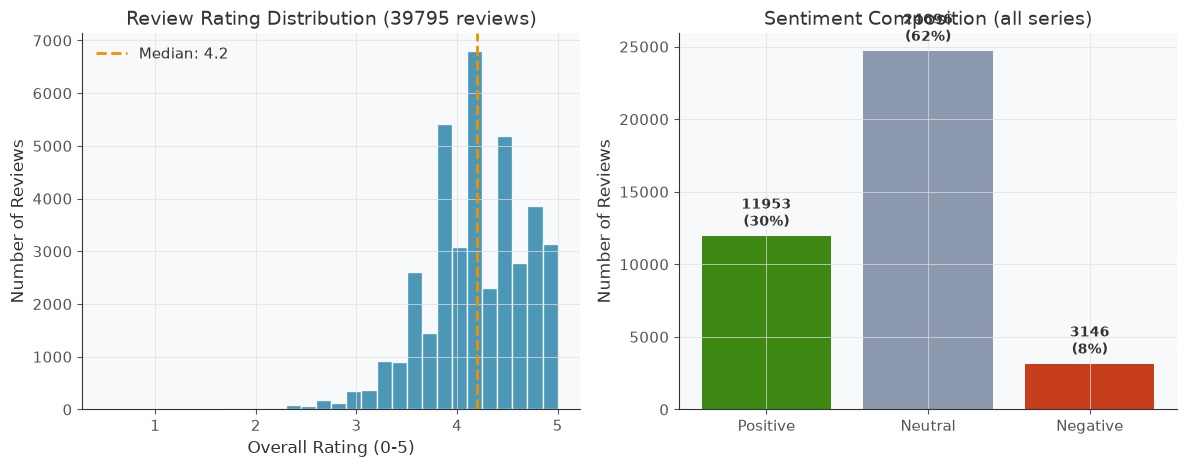

In [8]:
# Stage-1 visualization: overall sentiment landscape
valid = reviews[reviews.rating_overall > 0]
tot_pos = int(senti.positive_cnt.sum())
tot_neu = int(senti.neutral_cnt.sum())
tot_neg = int(senti.negative_cnt.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Left: distribution of review-level overall rating
axes[0].hist(valid.rating_overall, bins=30, color=COLORS['blue'], edgecolor='white', alpha=0.85)
axes[0].axvline(valid.rating_overall.median(), color=COLORS['orange'], linestyle='--',
                linewidth=2, label='Median: %.1f' % valid.rating_overall.median())
axes[0].set_title('Review Rating Distribution (%d reviews)' % len(valid))
axes[0].set_xlabel('Overall Rating (0-5)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend(loc='upper left', frameon=False)

# Right: sentiment composition across all reviews
labels = ['Positive', 'Neutral', 'Negative']
vals = [tot_pos, tot_neu, tot_neg]
cols = [COLORS['green'], COLORS['gray'], COLORS['red']]
bars = axes[1].bar(labels, vals, color=cols)
axes[1].set_title('Sentiment Composition (all series)')
axes[1].set_ylabel('Number of Reviews')
total = sum(vals)
for b, v in zip(bars, vals):
    axes[1].annotate('%d\n(%.0f%%)' % (v, 100*v/total),
                     xy=(b.get_x()+b.get_width()/2, b.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(FIG, 'sentiment_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.7 三表对齐：分析就绪表（阶段一核心成果）

`analysis_input.csv` 把舆情指标、销量指标、车型配置按 `series_id` 合并成**一行一车系**的分析就绪表，直接作为后续建模与归因的输入。

In [9]:
# The crown jewel of Stage 1: the three-table alignment.
# analysis_input.csv merges sentiment + sales + vehicle specs into one
# analysis-ready table, one row per series.
print('=== Analysis-ready table (analysis_input.csv) ===')
print('Shape:', analysis.shape, '(1 row = 1 series)')
print()
print('Columns grouped by origin:')
senti_cols = ['review_count','avg_rating','positive_ratio','negative_ratio']
sales_cols = ['total_sales','avg_monthly_sales','n_months','log_avg_monthly_sales']
spec_cols  = ['brand','category','official_price_wan','vehicle_class','energy_type']
print('  Sentiment :', senti_cols)
print('  Sales     :', sales_cols)
print('  Vehicle   :', spec_cols)
print()
print(analysis[['series_name'] + senti_cols[:2] + sales_cols[:2] + spec_cols[:3]].head(6).to_string())

=== Analysis-ready table (analysis_input.csv) ===
Shape: (490, 30) (1 row = 1 series)

Columns grouped by origin:
  Sentiment : ['review_count', 'avg_rating', 'positive_ratio', 'negative_ratio']
  Sales     : ['total_sales', 'avg_monthly_sales', 'n_months', 'log_avg_monthly_sales']
  Vehicle   : ['brand', 'category', 'official_price_wan', 'vehicle_class', 'energy_type']

  series_name  review_count  avg_rating  total_sales  avg_monthly_sales brand category  official_price_wan
0        奥迪Q3           100    3.931000     205966.0        3886.150943    奥迪      SUV               27.58
1        银河E5            87    4.191954     221902.0        9647.913043  吉利银河      SUV               10.98
2  红旗HS3 PHEV            84    4.211905      47428.0        2258.476190    红旗      SUV               16.18
3       零跑C16            95    4.220000     138838.0        5553.520000  零跑汽车      SUV               16.98
4      广汽本田P7            27    4.255556       4906.0         327.066667    本田      SUV     

### 2.8 阶段一成果检验：口碑与销量的关系

用对齐后的数据画「正面评价比例 vs 月均销量（对数）」散点，并叠加线性趋势线，直观检验口碑与销量是否存在关联——这正是对齐工作的价值所在。

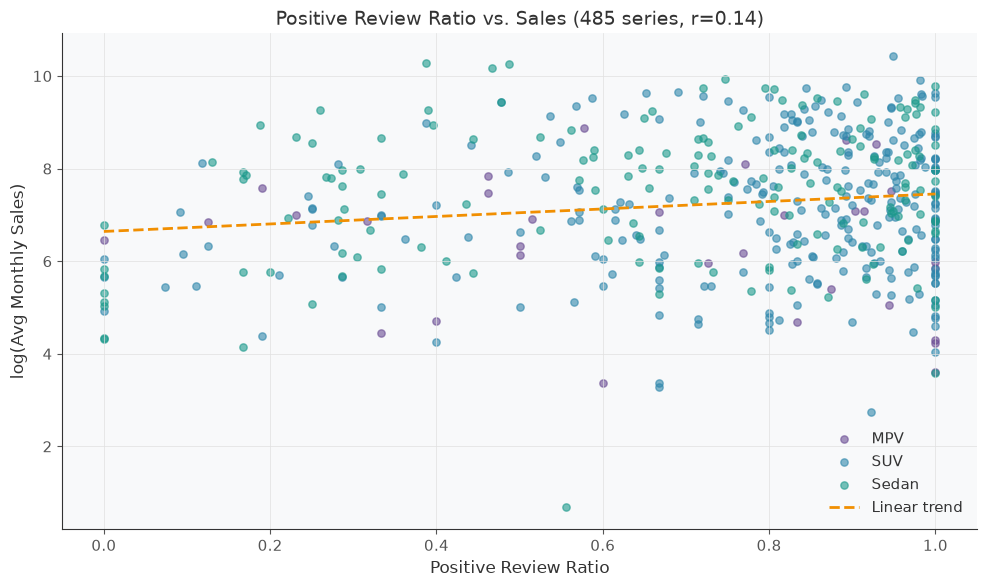

In [10]:
# Stage-1 payoff chart: does word-of-mouth relate to sales?
# Scatter positive_ratio vs (log) average monthly sales, colored by category.
df = analysis.dropna(subset=['positive_ratio', 'log_avg_monthly_sales', 'category']).copy()
CAT_EN = {'SUV': 'SUV', '轿车': 'Sedan', 'MPV': 'MPV'}
df['cat_en'] = df['category'].map(CAT_EN).fillna('Other')

fig, ax = plt.subplots(figsize=(10, 6))
palette = {'SUV': COLORS['blue'], 'Sedan': COLORS['teal'],
           'MPV': COLORS['purple'], 'Other': COLORS['gray']}
for cat, sub in df.groupby('cat_en'):
    ax.scatter(sub['positive_ratio'], sub['log_avg_monthly_sales'],
               s=28, alpha=0.6, color=palette.get(cat, COLORS['gray']), label=cat)

# overall trend line
z = np.polyfit(df['positive_ratio'], df['log_avg_monthly_sales'], 1)
xs = np.linspace(df['positive_ratio'].min(), df['positive_ratio'].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=COLORS['orange'], linewidth=2,
        linestyle='--', label='Linear trend')
corr = df['positive_ratio'].corr(df['log_avg_monthly_sales'])
ax.set_title('Positive Review Ratio vs. Sales (%d series, r=%.2f)' % (len(df), corr))
ax.set_xlabel('Positive Review Ratio')
ax.set_ylabel('log(Avg Monthly Sales)')
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG, 'sentiment_vs_sales.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.9 数据质量与覆盖检查

In [11]:
# Data quality checks across the prepared datasets
print('Sales   duplicated rows :', sales.duplicated().sum())
print('Vehicle duplicated rows :', vehicles.duplicated().sum())
print()
print('Series coverage:')
print('  sales    :', sales.series_id.nunique())
print('  vehicles :', vehicles.series_id.nunique())
print('  mapping  :', series_map['统一后series_id'].nunique())
print('  sentiment:', senti.series_id.nunique())
print('  aligned  :', analysis.series_id.nunique())
print()
print('Missing-value share in analysis table (top 5 columns):')
miss = (analysis.isna().mean().sort_values(ascending=False) * 100).round(1)
print(miss.head(5).to_string())

Sales   duplicated rows : 0
Vehicle duplicated rows : 0

Series coverage:
  sales    : 1122
  vehicles : 1139
  mapping  : 1139
  sentiment: 490
  aligned  : 490

Missing-value share in analysis table (top 5 columns):
positive_ratio           0.8
negative_ratio           0.8
log_avg_monthly_sales    0.2
category                 0.2
brand                    0.2


### 2.10 阶段一产出汇总

In [12]:
stage1_outputs = {
    'sales.csv (monthly sales)':        sales.shape,
    'vehicles.csv (specs)':             vehicles.shape,
    'series_mapping.csv (ID bridge)':   series_map.shape,
    'sentiment_reviews.csv (raw)':      reviews.shape,
    'sentiment_summary.csv (series)':   senti.shape,
    'analysis_input.csv (aligned)':     analysis.shape,
}
for k, v in stage1_outputs.items():
    print('%-34s %6d rows x %3d cols' % (k, v[0], v[1]))
print('\nStage 1 complete: data collected, cleaned, aligned into an analysis-ready table.')

sales.csv (monthly sales)           33845 rows x   8 cols
vehicles.csv (specs)                 4334 rows x  92 cols
series_mapping.csv (ID bridge)       1139 rows x  12 cols
sentiment_reviews.csv (raw)         40054 rows x  26 cols
sentiment_summary.csv (series)        490 rows x  26 cols
analysis_input.csv (aligned)          490 rows x  30 cols

Stage 1 complete: data collected, cleaned, aligned into an analysis-ready table.


## 3. 阶段二：数据筛选与探索性可视化

阶段二实现项目规划的 Step 3、Step 7、Step 13：
- **Step 3**：筛选连续 ≥24 个月有销量的车型。
- **Step 7**：绘制销量趋势、车型分类、硬件特征可视化。
- **Step 13**：汇总全量时序统计（中断次数、最长连续、最长断档）。

### 3.1 构造时间索引与连续月份辅助函数

In [13]:
sales['period'] = sales['year'] * 12 + (sales['month'] - 1)
sales['date'] = pd.to_datetime(dict(year=sales.year, month=sales.month, day=1))

def runs_info(periods):
    """Return (longest_run, interrupt_count, longest_gap, total_months)."""
    p = np.sort(np.unique(periods))
    if len(p) == 0:
        return 0, 0, 0, 0
    diffs = np.diff(p)
    runs, gaps, cur = [], [], 1
    for d in diffs:
        if d == 1:
            cur += 1
        else:
            runs.append(cur)
            gaps.append(d - 1)
            cur = 1
    runs.append(cur)
    longest = int(max(runs))
    n_interrupt = int(np.sum(diffs > 1))
    longest_gap = int(max(gaps)) if gaps else 0
    return longest, n_interrupt, longest_gap, len(p)

### 3.2 英文标签映射

图表使用英文标签以避免中文字体缺失导致的乱码；这里把中文分类值（车型类别 / 级别 / 能源类型）映射为英文。

In [14]:
CATEGORY_MAP = {'SUV': 'SUV', '轿车': 'Sedan', 'MPV': 'MPV'}
VEHICLE_CLASS_MAP = {
    '中型车': 'Mid-size Sedan', '中大型车': 'Large Sedan', '中型SUV': 'Mid-size SUV',
    '紧凑型SUV': 'Compact SUV', '紧凑型车': 'Compact Sedan', '中大型SUV': 'Large SUV',
    '小型SUV': 'Small SUV', '大型SUV': 'Full-size SUV', '中大型MPV': 'Large MPV',
    '小型车': 'Small Sedan', '微型车': 'Mini Car', '中型MPV': 'Mid-size MPV',
    '紧凑型MPV': 'Compact MPV', '大型车': 'Full-size Sedan', '大型MPV': 'Full-size MPV',
    '微面': 'Mini Van', '轻客': 'Light Van', 'MPV': 'MPV',
}
ENERGY_TYPE_MAP = {
    '燃油': 'Gasoline', '纯电动': 'BEV', '插电混动': 'PHEV', '增程式': 'EREV',
    '油电混动': 'HEV', '插混+纯电': 'PHEV+BEV', '其他': 'Other',
}

sales['category_en'] = sales['category'].map(CATEGORY_MAP)
vehicles['vehicle_class_en'] = vehicles['vehicle_class'].map(VEHICLE_CLASS_MAP)
vehicles['energy_type_en'] = vehicles['energy_type'].map(ENERGY_TYPE_MAP)
print('Mappings applied.')

Mappings applied.


### 3.3 Step 13：全量时序汇总（全部 1,122 个车系）

对每一个车系计算：总月数、最长连续月数、中断次数、最长断档月数。

In [15]:
summary_rows = []
for sid, g in sales.groupby('series_id'):
    longest, nint, gap, total = runs_info(g['period'].values)
    summary_rows.append({
        'series_id': sid,
        'series_name': g['series_name'].iloc[0],
        'brand': g['brand'].iloc[0],
        'category': g['category'].iloc[0],
        'total_months': total,
        'longest_run_months': longest,
        'interrupt_count': nint,
        'longest_gap_months': gap,
        'first_year': int(g['year'].min()),
        'last_year': int(g['year'].max()),
    })

timeseries_summary = pd.DataFrame(summary_rows).sort_values('longest_run_months', ascending=False)
timeseries_summary.to_csv(os.path.join(PROC, 'timeseries_summary.csv'), index=False, encoding='utf-8-sig')
print('Shape:', timeseries_summary.shape)
print(timeseries_summary.head(10))
print('\nBasic stats:')
print(timeseries_summary[['total_months', 'longest_run_months', 'interrupt_count', 'longest_gap_months']].describe())

Shape: (1122, 10)
    series_id series_name brand category  total_months  longest_run_months  \
0         100        奥迪Q3    奥迪      SUV            53                  53   
221       352         昂科威    别克      SUV            53                  53   
232       398         帕萨特    大众       轿车            53                  53   
231       397          凌渡    大众       轿车            53                  53   
229       393          朗逸    大众       轿车            53                  53   
228      3928       奔驰GLB    奔驰      SUV            53                  53   
226      3762     Model 3   特斯拉       轿车            53                  53   
224      3736     凯迪拉克CT5  凯迪拉克       轿车            53                  53   
222       353       别克GL8    别克      MPV            53                  53   
480        95        奥迪A3    奥迪       轿车            53                  53   

     interrupt_count  longest_gap_months  first_year  last_year  
0                  0                   0        2022     

### 3.4 Step 3：筛选连续 ≥24 个月的车系

In [16]:
MIN_RUN = 24
qualified_ids = timeseries_summary[timeseries_summary['longest_run_months'] >= MIN_RUN]['series_id'].tolist()
print(f'Series with >= {MIN_RUN} consecutive months: {len(qualified_ids)}')

sales_filtered = sales[sales['series_id'].isin(qualified_ids)].copy()
sales_filtered.to_csv(os.path.join(PROC, 'sales_filtered_24m.csv'), index=False, encoding='utf-8-sig')
print(f'Filtered sales rows: {len(sales_filtered)}')

vehicles_filtered = vehicles[vehicles['series_id'].isin(qualified_ids)].drop_duplicates('series_id')
print(f'Filtered vehicle series rows: {len(vehicles_filtered)}')

Series with >= 24 consecutive months: 669
Filtered sales rows: 28838
Filtered vehicle series rows: 669


### 3.5 Step 7-1：销量趋势可视化

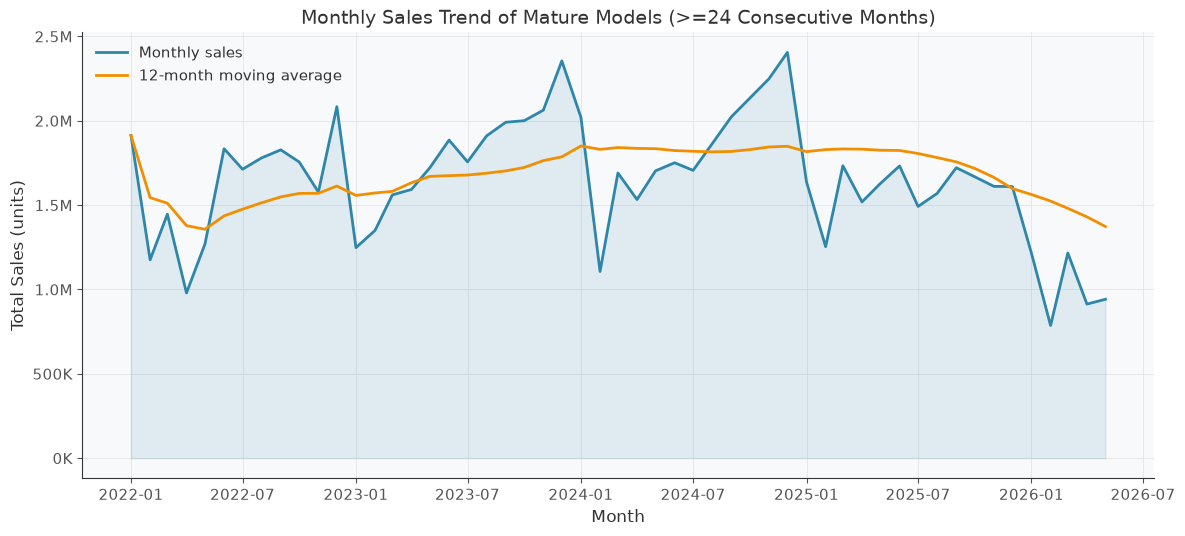

In [17]:
mt = sales_filtered.groupby('date')['monthly_sales'].sum().reset_index().sort_values('date')
mt['rolling_12m'] = mt['monthly_sales'].rolling(window=12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.fill_between(mt['date'], mt['monthly_sales'], color=COLORS['blue'], alpha=0.12)
ax.plot(mt['date'], mt['monthly_sales'], color=COLORS['blue'], linewidth=2, label='Monthly sales')
ax.plot(mt['date'], mt['rolling_12m'], color=COLORS['orange'], linewidth=2, label='12-month moving average')
ax.set_title('Monthly Sales Trend of Mature Models (>=24 Consecutive Months)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (units)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.legend(loc='upper left', frameon=False)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(os.path.join(FIG, 'sales_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Step 7-2：车型分类分布可视化

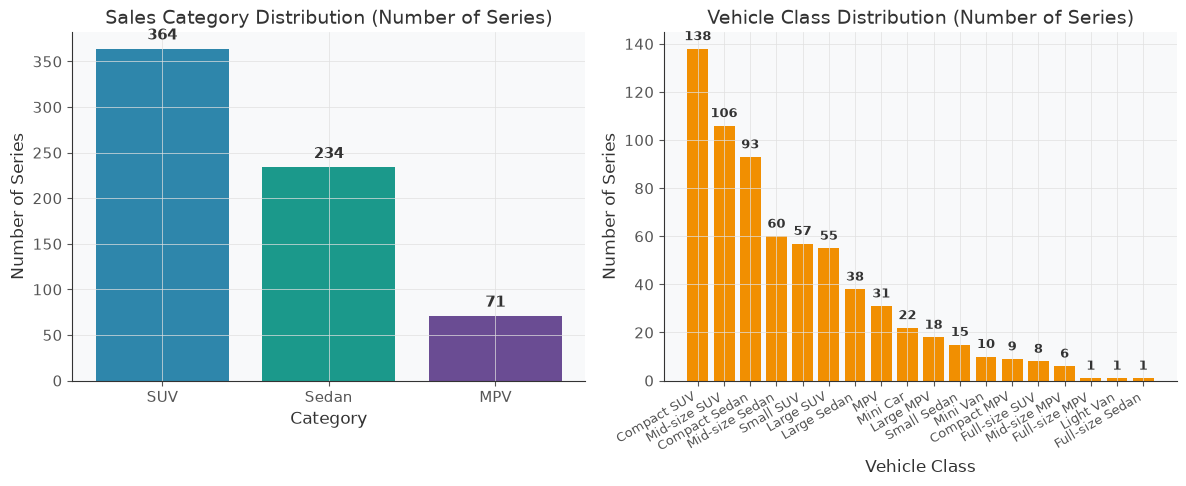

In [18]:
cat = sales_filtered.groupby('category_en')['series_id'].nunique().sort_values(ascending=False)
vclass = vehicles_filtered['vehicle_class_en'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: sales category
bars1 = axes[0].bar(cat.index, cat.values, color=[COLORS['blue'], COLORS['teal'], COLORS['purple']])
axes[0].set_title('Sales Category Distribution (Number of Series)')
axes[0].set_ylabel('Number of Series')
axes[0].set_xlabel('Category')
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 4), textcoords='offset points',
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: vehicle class
x_pos = np.arange(len(vclass))
bars2 = axes[1].bar(x_pos, vclass.values, color=COLORS['orange'])
axes[1].set_title('Vehicle Class Distribution (Number of Series)')
axes[1].set_ylabel('Number of Series')
axes[1].set_xlabel('Vehicle Class')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(vclass.index, rotation=30, ha='right', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    axes[1].annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(FIG, 'category_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Step 7-3：硬件特征分布可视化

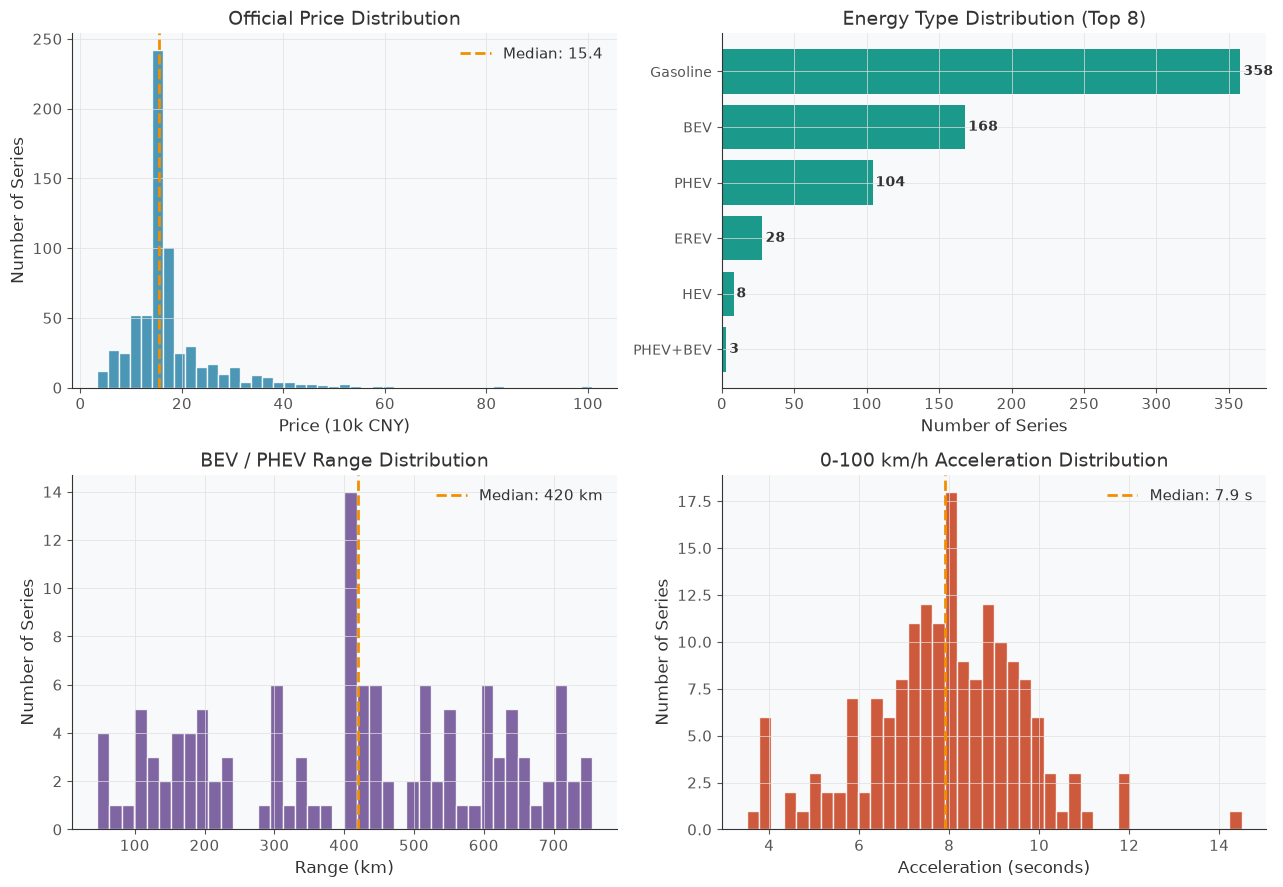

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Price
price = vehicles_filtered['official_price_wan'].dropna()
axes[0, 0].hist(price, bins=45, color=COLORS['blue'], edgecolor='white', alpha=0.85)
axes[0, 0].axvline(price.median(), color=COLORS['orange'], linestyle='--', linewidth=2,
                   label=f'Median: {price.median():.1f}')
axes[0, 0].set_title('Official Price Distribution')
axes[0, 0].set_xlabel('Price (10k CNY)')
axes[0, 0].set_ylabel('Number of Series')
axes[0, 0].legend(loc='upper right', frameon=False)

# Energy type
et = vehicles_filtered['energy_type_en'].value_counts().head(8)
axes[0, 1].barh(np.arange(len(et)), et.values, color=COLORS['teal'])
axes[0, 1].set_yticks(np.arange(len(et)))
axes[0, 1].set_yticklabels(et.index, fontsize=10)
axes[0, 1].invert_yaxis()
axes[0, 1].set_title('Energy Type Distribution (Top 8)')
axes[0, 1].set_xlabel('Number of Series')
for i, v in enumerate(et.values):
    axes[0, 1].text(v + 2, i, f'{int(v)}', va='center', fontsize=10, fontweight='bold')

# Range
rng = vehicles_filtered['battery_range_km'].dropna()
axes[1, 0].hist(rng, bins=40, color=COLORS['purple'], edgecolor='white', alpha=0.85)
axes[1, 0].axvline(rng.median(), color=COLORS['orange'], linestyle='--', linewidth=2,
                   label=f'Median: {rng.median():.0f} km')
axes[1, 0].set_title('BEV / PHEV Range Distribution')
axes[1, 0].set_xlabel('Range (km)')
axes[1, 0].set_ylabel('Number of Series')
axes[1, 0].legend(loc='upper right', frameon=False)

# Acceleration
acc = vehicles_filtered['acceleration_0_100_s'].dropna()
axes[1, 1].hist(acc, bins=40, color=COLORS['red'], edgecolor='white', alpha=0.85)
axes[1, 1].axvline(acc.median(), color=COLORS['orange'], linestyle='--', linewidth=2,
                   label=f'Median: {acc.median():.1f} s')
axes[1, 1].set_title('0-100 km/h Acceleration Distribution')
axes[1, 1].set_xlabel('Acceleration (seconds)')
axes[1, 1].set_ylabel('Number of Series')
axes[1, 1].legend(loc='upper right', frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIG, 'hardware_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.8 阶段二产出汇总

| 产出 | 说明 | 文件 |
|------|------|------|
| 筛选后销量子集 | 669 个连续≥24月车系 | `data/processed/sales_filtered_24m.csv` |
| 时序汇总 | 1,122 系的中断/连续/断档统计 | `data/processed/timeseries_summary.csv` |
| 销量趋势图 | 月度总量 + 12月移动平均 | `figures/sales_trend.png` |
| 车型分类图 | 销量类别 + 车辆级别 | `figures/category_distribution.png` |
| 硬件特征图 | 价格/能源/续航/加速 | `figures/hardware_features.png` |

In [20]:
print('Stage 2 outputs:')
for f in ['sales_filtered_24m.csv', 'timeseries_summary.csv']:
    path = os.path.join(PROC, f)
    print(f'  {path}  ({os.path.getsize(path)/1024:.1f} KB)')
for f in ['sales_trend.png', 'category_distribution.png', 'hardware_features.png']:
    path = os.path.join(FIG, f)
    print(f'  {path}  ({os.path.getsize(path)/1024:.1f} KB)')

Stage 2 outputs:
  /Users/ye/dev/projects/AutoPulse/data/processed/sales_filtered_24m.csv  (2021.0 KB)
  /Users/ye/dev/projects/AutoPulse/data/processed/timeseries_summary.csv  (57.6 KB)
  /Users/ye/dev/projects/AutoPulse/figures/sales_trend.png  (116.9 KB)
  /Users/ye/dev/projects/AutoPulse/figures/category_distribution.png  (108.4 KB)
  /Users/ye/dev/projects/AutoPulse/figures/hardware_features.png  (133.2 KB)


## 4. 结论与下一步

**已完成**：
- 阶段一：数据准备（6 份数据集，采集 / 清洗 / 对齐 / 分析就绪表）
- 阶段二：筛选与探索性可视化（Step 3 / Step 7 / Step 13）

**下一步**：阶段三 —— 销量预测建模（Step 8–11）：
1. ARIMA 基线模型
2. LSTM 深度学习
3. Prophet
4. XGBoost
5. Prophet + XGBoost 融合
6. 多模型对比评估

筛选出的 669 车系数据集（`sales_filtered_24m.csv`）与对齐的分析表（`analysis_input.csv`）将作为后续建模与归因的输入。